In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib import ticker

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [12]:
from utilize.mesh_io import read_mshv2_triangular
from scipy.linalg import cho_factor, cho_solve

node_pos_np, triangles = read_mshv2_triangular("../pd_stretch_tissue_mesh_init_2.msh")

v_min, v_max = -1.4, 0.6

First Exploration

In [14]:
Y_1 = np.loadtxt(f"Y_ekf-1.csv", delimiter=",")
low_value_1 = np.loadtxt(f"low_value_indices-1.csv", delimiter=",", dtype=int)

low_value_mask_1 = np.zeros(triangles.shape[0], dtype=bool)
low_value_mask_1[low_value_1] = True

V_1, F_1 = read_mshv2_triangular("pd_contact[5, 96]_step010.msh")

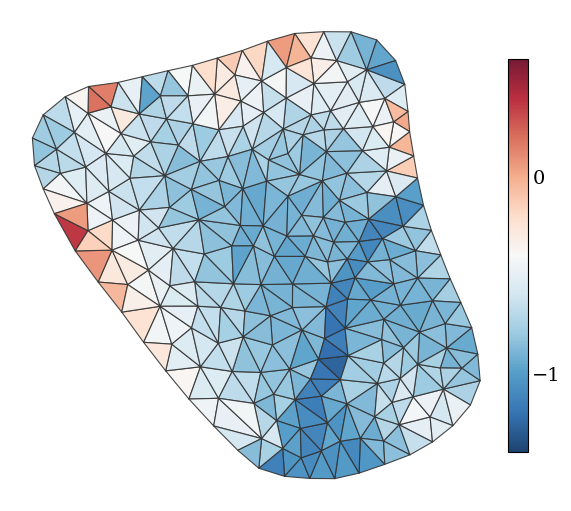

In [15]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.log10(np.sqrt(np.diag(Y_1)))
# v_min, v_max = inform.min(), inform.max()
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im1 = ax1.tripcolor(V_1[:, 0], V_1[:, 1], F_1, 
                    facecolors=inform, shading='flat', 
                    edgecolors='#333333', linewidth=0.8, alpha=0.9, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

plt.savefig(f"stiffness_inform-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 33 low-value elements out of 384 total elements.


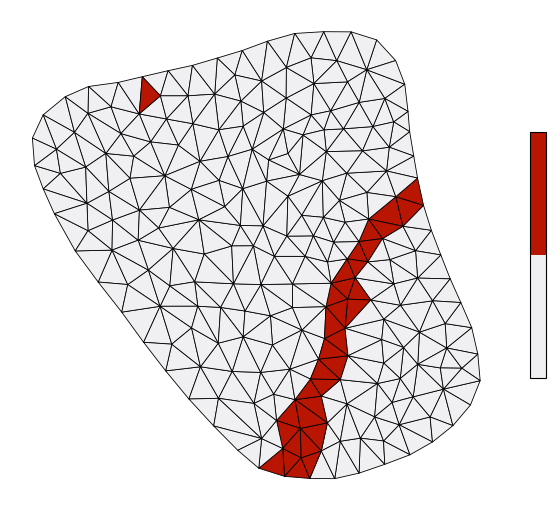

In [10]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(V_1[:, 0], V_1[:, 1], F_1, 
                    facecolors=low_value_mask_1.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {low_value_mask_1.sum()} low-value elements out of {low_value_mask_1.size} total elements.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9698

  Band PR-AUC: 0.8768

  Local Robust CNR: 1.6096

  Local FDR: 2.5376

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9851 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.7894 (Higher is better)

  [Field Metric 3] Robust CNR: 1.2942 (Higher is better)

  [Field Metric 4] FDR: 3.0493 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.7308

  [Seg Metric 2] IoU:        0.5758

  [Seg Metric 3] Precision:  0.5758

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9586
  
  [Seg Metric 6] F1-score:   0.7308